In [1]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [2]:
train_clean = pd.read_csv("../data/train_clean.csv")


In [3]:

x = train_clean.drop("SalePrice", axis=1)
y = train_clean["SalePrice"]
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

In [4]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=429.1934260128778))
])

In [5]:
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",429.1934260128778
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [6]:
y_pred = pipeline.predict(x_val)

In [7]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE: ", rmse)

RMSE:  0.1462682146619649


In [8]:
r2 = r2_score(y_val, y_pred)
print("R2 Score: ", r2)

R2 Score:  0.8853529967224225


In [9]:
actual_price = np.expm1(y_val)
predicted_price = np.expm1(y_pred)

comparison = pd.DataFrame({
    "Actual price $": actual_price,
    "Predicted price $": predicted_price
})
comparison = comparison.reset_index(drop=True)
comparison.head(10)

,Actual price $,Predicted price $
0,154500.0,148267.740147
1,325000.0,308878.494388
2,115000.0,105201.320868
3,159000.0,157259.671284
4,315500.0,299181.431449
5,75500.0,80917.249122
6,311500.0,230824.245486
7,146000.0,144516.556494
8,84500.0,77064.783457
9,135500.0,139344.303089


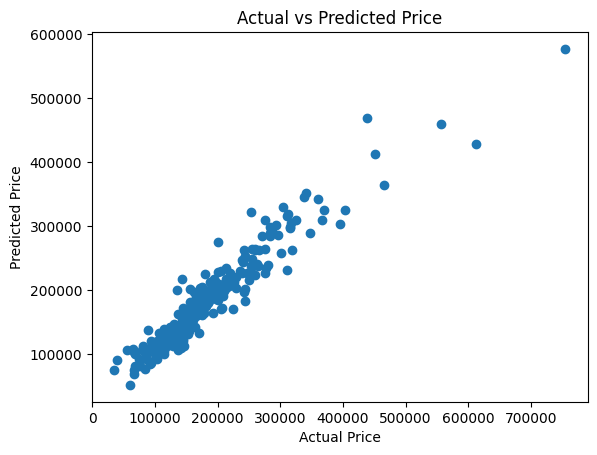

In [11]:
import matplotlib.pyplot as plt

plt.scatter(actual_price, predicted_price)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [12]:
joblib.dump(pipeline, "../models/final_house_price_model.pkl")

['../models/final_house_price_model.pkl']